# WiFi AP Inventory — 5 GHz Passive Monitor Captures

Parses beacon/probe-response frames from the exp156 pcap captures (monad-02, 03, 04, 05, 06) to produce:
- AP inventory table: SSID, BSSID, channel, security, beacon interval, vendor
- Channel occupancy map
- Per-AP RSSI as seen by each Pi
- Vendor / manufacturer breakdown

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict
import struct

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scapy.all import rdpcap, Dot11, Dot11Beacon, Dot11Elt, Dot11ProbeResp, RadioTap

sns.set_theme(style='darkgrid', palette='tab10')
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 80)

In [2]:
from pathlib import Path as _P
_RAW = _P('/Users/admin/FleetManager/artifacts/analysis/exp156/raw')
PCAPS = {
    'monad-02': str(_RAW / 'run-549c0c06__report-replay__dev-monad-02__wifi-5g-monitor__16dcbb3c.pcap'),
    'monad-03': str(_RAW / 'run-b611756a__report-replay__dev-monad-03__wifi-5g-monitor__77afefb3.pcap'),
    'monad-04': str(_RAW / 'run-f6e6cc74__report-replay__dev-monad-04__wifi-5g-monitor__f98fca7e.pcap'),
    'monad-05': str(_RAW / 'run-807b41a8__report-replay__dev-monad-05__wifi-5g-monitor__639ed56d.pcap'),
    'monad-06': str(_RAW / 'run-b2bbce79__report-replay__dev-monad-06__wifi-5g-monitor__1b177758.pcap'),
}

# OUI vendor lookup. Keep canonical vendor labels so vendor charts roll up
# physical OUIs and known virtual-BSSID aliases into the same bucket.
OUI_DB = {
    '00:17:f2': 'Apple', '04:4b:ed': 'Apple', '08:6d:41': 'Apple', '0c:74:c2': 'Apple',
    '10:9a:dd': 'Apple', '14:98:77': 'Apple', '18:65:90': 'Apple', '1c:36:bb': 'Apple',
    '20:a2:e4': 'Apple', '28:6a:b8': 'Apple', '3c:22:fb': 'Apple', '40:4d:7f': 'Apple',
    '54:e4:3a': 'Apple', '5c:97:f3': 'Apple', '60:f8:1d': 'Apple', '6c:40:08': 'Apple',
    '70:70:0d': 'Apple', '78:d7:5f': 'Apple', '8c:85:90': 'Apple', 'a4:83:e7': 'Apple',
    'ac:61:ea': 'Apple', 'b8:ff:61': 'Apple', 'dc:2b:2a': 'Apple', 'f0:18:98': 'Apple',
    '00:50:f2': 'Microsoft', 'e8:9d:87': 'TP-Link', '54:af:97': 'TP-Link', '98:da:c4': 'TP-Link',
    '5c:62:8b': 'TP-Link', '7e:62:8b': 'TP-Link', '10:fe:ed': 'TP-Link',
    'c8:3a:35': 'TP-Link', '64:70:02': 'TP-Link', 'b0:be:76': 'TP-Link',
    '90:9a:4a': 'TP-Link', 'a0:f3:c1': 'TP-Link', '2c:3b:7d': 'Asus', '04:d4:c4': 'Asus',
    '10:c3:7b': 'Asus', '2c:fd:a1': 'Asus', '50:46:5d': 'Asus', 'ac:9e:17': 'Asus',
    'f8:32:e4': 'Asus', '00:0c:e7': 'Ubiquiti', '04:18:d6': 'Ubiquiti', '24:a4:3c': 'Ubiquiti',
    '44:d9:e7': 'Ubiquiti', '68:72:51': 'Ubiquiti', '80:2a:a8': 'Ubiquiti', 'b4:fb:e4': 'Ubiquiti',
    'b6:fb:e4': 'Ubiquiti', 'e4:38:83': 'Ubiquiti', 'f6:38:83': 'Ubiquiti', 'f2:38:83': 'Ubiquiti',
    'ee:38:83': 'Ubiquiti', 'ea:38:83': 'Ubiquiti', 'fa:38:83': 'Ubiquiti', '18:e8:29': 'Ubiquiti',
    'ac:8b:a9': 'Ubiquiti', 'b6:8b:a9': 'Ubiquiti', 'ba:8b:a9': 'Ubiquiti', 'b2:8b:a9': 'Ubiquiti',
    'd0:21:f9': 'Ubiquiti', 'f0:9f:c2': 'Ubiquiti', '00:1a:11': 'Google', '54:60:09': 'Google',
    'a4:77:33': 'Google', 'f4:f5:e8': 'Google', '94:b4:0f': 'Google', 'e4:f0:42': 'Google',
    '00:18:4d': 'Netgear', '20:e5:2a': 'Netgear', '28:c6:8e': 'Netgear', '30:46:9a': 'Netgear',
    '44:94:fc': 'Netgear', '6c:b0:ce': 'Netgear', '9c:3d:cf': 'Netgear', 'a0:40:a0': 'Netgear',
    'c0:3f:0e': 'Netgear', 'e0:91:f5': 'Netgear', '00:24:01': 'Xiaomi', '28:6c:07': 'Xiaomi',
    '34:ce:00': 'Xiaomi', '58:44:98': 'Xiaomi', '64:09:80': 'Xiaomi', '8c:be:be': 'Xiaomi',
    '9c:99:a0': 'Xiaomi', 'ac:f7:f3': 'Xiaomi', 'f4:8b:32': 'Xiaomi', 'fc:64:ba': 'Xiaomi',
    '00:26:b9': 'Huawei', '04:bd:70': 'Huawei', '2c:ab:00': 'Huawei', '48:46:fb': 'Huawei',
    '70:8a:09': 'Huawei', '9c:74:1a': 'Huawei', 'b4:86:55': 'Huawei', 'e8:cd:2d': 'Huawei',
    '00:1f:33': 'D-Link', '14:d6:4d': 'D-Link', '28:10:7b': 'D-Link', '34:08:04': 'D-Link',
    '58:d5:6e': 'D-Link', '84:c9:b2': 'D-Link', 'c8:be:19': 'D-Link',
    '34:2c:c4': 'Compal', '90:5c:44': 'Compal', '68:02:b8': 'Compal', '38:43:7d': 'Compal',
    'ac:f8:cc': 'CommScope', '64:fd:96': 'Sagemcom', 'a4:86:db': 'Guangdong Juan',
}

def oui_vendor(mac: str) -> str:
    if not isinstance(mac, str) or not mac:
        return 'Unknown'
    oui = mac[:8].lower()
    if oui in OUI_DB:
        return OUI_DB[oui]
    first_byte = int(oui[:2], 16)
    if first_byte & 0x02:
        return 'Locally administered / virtual BSSID'
    return 'Unknown'

print('Libraries loaded.')

Libraries loaded.


In [3]:
def freq_to_channel(freq: int) -> int:
    """Convert 5 GHz frequency (MHz) to channel number."""
    if 5180 <= freq <= 5825:
        return (freq - 5000) // 5
    if 5955 <= freq <= 7115:
        return (freq - 5950) // 5
    return 0


def parse_security(cap_int: int, elt_list) -> str:
    """Determine security mode from capability field + IEs."""
    has_rsn = False
    has_wpa = False
    for elt in elt_list:
        if elt.ID == 48:  # RSN (WPA2/WPA3)
            has_rsn = True
        if elt.ID == 221 and elt.info[:4] == b'\x00P\xf2\x01':  # WPA vendor IE
            has_wpa = True
    if has_rsn and has_wpa:
        return 'WPA2/WPA3+WPA'
    if has_rsn:
        return 'WPA2/WPA3'
    if has_wpa:
        return 'WPA'
    if cap_int & 0x10:  # Privacy bit
        return 'WEP'
    return 'Open'


def parse_beacon(pkt):
    """Extract all fields from a beacon/probe-response frame."""
    if not pkt.haslayer(Dot11):
        return None
    d11 = pkt[Dot11]
    bssid = d11.addr3 or ''

    # RSSI from RadioTap
    rssi = None
    freq = None
    if pkt.haslayer(RadioTap):
        rt = pkt[RadioTap]
        rssi = getattr(rt, 'dBm_AntSignal', None)
        freq = getattr(rt, 'ChannelFrequency', None)

    # Walk IEs
    ssid = ''
    beacon_interval = None
    cap_int = 0
    elt_list = []
    supported_rates = []
    vendor_tags = []

    if pkt.haslayer(Dot11Beacon):
        beacon_interval = pkt[Dot11Beacon].beacon_interval
        cap_int = int(pkt[Dot11Beacon].cap)
    elif pkt.haslayer(Dot11ProbeResp):
        beacon_interval = pkt[Dot11ProbeResp].beacon_interval
        cap_int = int(pkt[Dot11ProbeResp].cap)

    elt = pkt.getlayer(Dot11Elt)
    while elt:
        elt_list.append(elt)
        if elt.ID == 0:   # SSID
            try:
                ssid = elt.info.decode('utf-8', errors='replace')
            except Exception:
                ssid = ''
        elif elt.ID in (1, 50):  # Supported Rates / Extended Supported Rates
            for b in elt.info:
                rate = (b & 0x7F) * 0.5
                supported_rates.append(rate)
        elif elt.ID == 221:  # Vendor Specific
            oui = elt.info[:3].hex(':') if len(elt.info) >= 3 else ''
            vendor_tags.append(oui)
        elt = elt.payload.getlayer(Dot11Elt) if elt.payload else None

    channel = freq_to_channel(freq) if freq else 0
    security = parse_security(cap_int, elt_list)
    max_rate = max(supported_rates) if supported_rates else None

    return {
        'bssid': bssid.upper(),
        'ssid': ssid,
        'freq_mhz': freq,
        'channel': channel,
        'rssi_dbm': rssi,
        'beacon_interval': beacon_interval,
        'security': security,
        'max_rate_mbps': max_rate,
        'vendor': oui_vendor(bssid),
        'vendor_ies': ', '.join(set(vendor_tags)) if vendor_tags else '',
    }


print('Parser defined.')

Parser defined.


In [4]:
# ── Fast loader: use pre-built CSV instead of re-parsing raw PCaps ──────
# wifi_5g_frames.csv was built by the dataset builder script
# and contains the same beacon/probe-response data with all needed columns.
_CSV = _P('/Users/admin/FleetManager/artifacts/analysis/exp156/wifi_5g_frames.csv')

df = pd.read_csv(_CSV)
if 'sensor' not in df.columns and 'pi_id' in df.columns:
    df['sensor'] = df['pi_id']
df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
df['bssid'] = df['bssid'].str.upper()
df['vendor'] = df['bssid'].apply(lambda m: oui_vendor(m.lower()) if isinstance(m, str) else 'Unknown')

# security: not available from beacon-only fast parse; set placeholder
df['security'] = 'Unknown'
df['beacon_interval'] = None
df['max_rate_mbps'] = None
df['vendor_ies'] = ''

if 'frame_subtype' in df.columns:
    df = df[df['frame_subtype'].isin(['Beacon', 'Probe Response'])].copy()
else:
    df = df[df['bssid'].notna() & (df['bssid'].str.len() > 0)].copy()

if df.empty:
    print('No records found.')
else:
    df = df[df['channel'].notna() & (df['channel'] > 0)].copy()
    print(f'Total records: {len(df):,} | Unique BSSIDs: {df["bssid"].nunique()}')
    print(f'Sensors: {sorted(df["sensor"].unique())}')


Total records: 12,189 | Unique BSSIDs: 46
Sensors: ['monad-02', 'monad-03', 'monad-04', 'monad-05', 'monad-06']


In [5]:
def agg_ap(g):
    return pd.Series({
        'ssid':            g['ssid'].mode().iloc[0] if len(g['ssid'].mode()) else '',
        'channel':         g['channel'].mode().iloc[0],
        'freq_mhz':        g['freq_mhz'].median(),
        'security':        g['security'].mode().iloc[0],
        'beacon_interval': g['beacon_interval'].median(),
        'max_rate_mbps':   g['max_rate_mbps'].max(),
        'vendor':          g['vendor'].mode().iloc[0],
        'rssi_median_dbm': g['rssi_dbm'].median(),
        'rssi_min_dbm':    g['rssi_dbm'].min(),
        'rssi_max_dbm':    g['rssi_dbm'].max(),
        'beacon_count':    len(g),
        'seen_by':         ', '.join(sorted(g['sensor'].unique())),
    })

ap_inv = pd.DataFrame()   # default empty
if not df.empty:
    ap_inv = df.groupby('bssid').apply(agg_ap, include_groups=False).reset_index()
    ap_inv = ap_inv.sort_values('rssi_median_dbm', ascending=False).reset_index(drop=True)
    ap_inv['ssid_display'] = ap_inv['ssid'].apply(lambda s: '(hidden)' if s == '' else s)
    print(f'Unique APs: {len(ap_inv)}')
    display(ap_inv[['bssid','ssid_display','channel','freq_mhz','security',
                    'max_rate_mbps','vendor','rssi_median_dbm','beacon_count','seen_by']])


Unique APs: 46


,bssid,ssid_display,channel,freq_mhz,security,max_rate_mbps,vendor,rssi_median_dbm,beacon_count,seen_by
0,34:2C:C4:9B:85:69,(hidden),40,5200.0,Unknown,NaN,Compal,-63.0,1898,"monad-02, monad-03, monad-04, monad-05, monad-06"
1,10:FE:ED:3B:28:10,(hidden),48,5240.0,Unknown,NaN,TP-Link,-72.0,1980,"monad-02, monad-03, monad-04, monad-05, monad-06"
2,2A:01:12:5D:A2:7A,(hidden),40,5200.0,Unknown,NaN,Locally administered / virtual BSSID,-80.0,371,monad-04
3,38:43:7D:EF:E8:15,(hidden),36,5180.0,Unknown,NaN,Compal,-83.0,1418,"monad-02, monad-03, monad-05, monad-06"
4,68:02:B8:4C:CE:F2,(hidden),40,5200.0,Unknown,NaN,Compal,-87.0,1038,"monad-02, monad-03, monad-05, monad-06"
5,A2:02:A5:AF:74:E4,(hidden),36,5180.0,Unknown,NaN,Locally administered / virtual BSSID,-87.0,8,"monad-03, monad-06"
6,90:5C:44:F7:EF:09,(hidden),36,5180.0,Unknown,NaN,Compal,-88.0,608,"monad-03, monad-04"
7,68:8F:C9:8F:0A:F8,(hidden),36,5180.0,Unknown,NaN,Unknown,-88.0,7,monad-03
8,B4:F2:67:3D:EC:2B,(hidden),40,5200.0,Unknown,NaN,Unknown,-88.0,304,monad-04
9,26:23:51:48:E9:C7,(hidden),44,5220.0,Unknown,NaN,Locally administered / virtual BSSID,-89.0,23,"monad-03, monad-06"


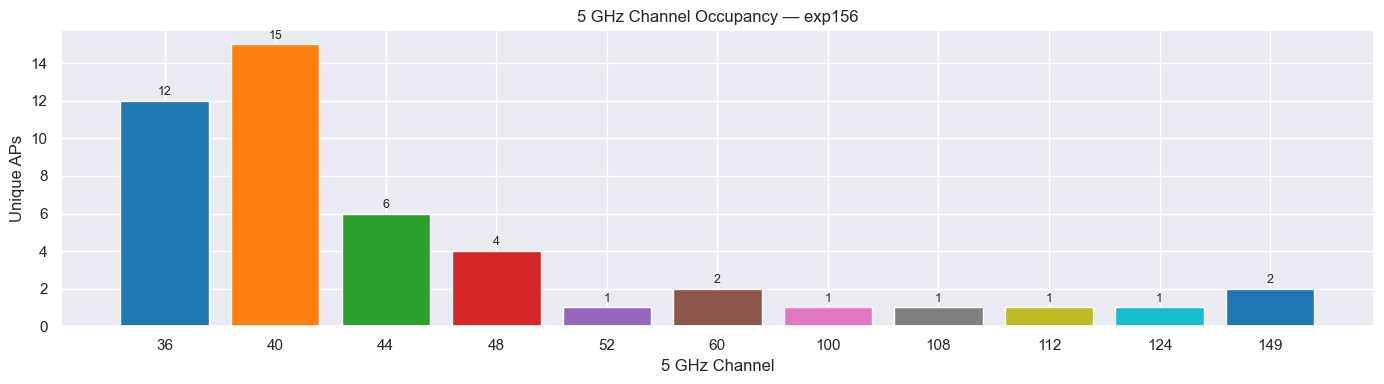

 channel  ap_count
      36        12
      40        15
      44         6
      48         4
      52         1
      60         2
     100         1
     108         1
     112         1
     124         1
     149         2


In [6]:
if not ap_inv.empty:
    ch_counts = ap_inv.groupby('channel').size().reset_index(name='ap_count').sort_values('channel')
    
    fig, ax = plt.subplots(figsize=(14, 4))
    bars = ax.bar(ch_counts['channel'].astype(str), ch_counts['ap_count'],
                  color=sns.color_palette('tab10', len(ch_counts)))
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_xlabel('5 GHz Channel')
    ax.set_ylabel('Unique APs')
    ax.set_title('5 GHz Channel Occupancy — exp156')
    plt.tight_layout()
    plt.show()
    print(ch_counts.to_string(index=False))


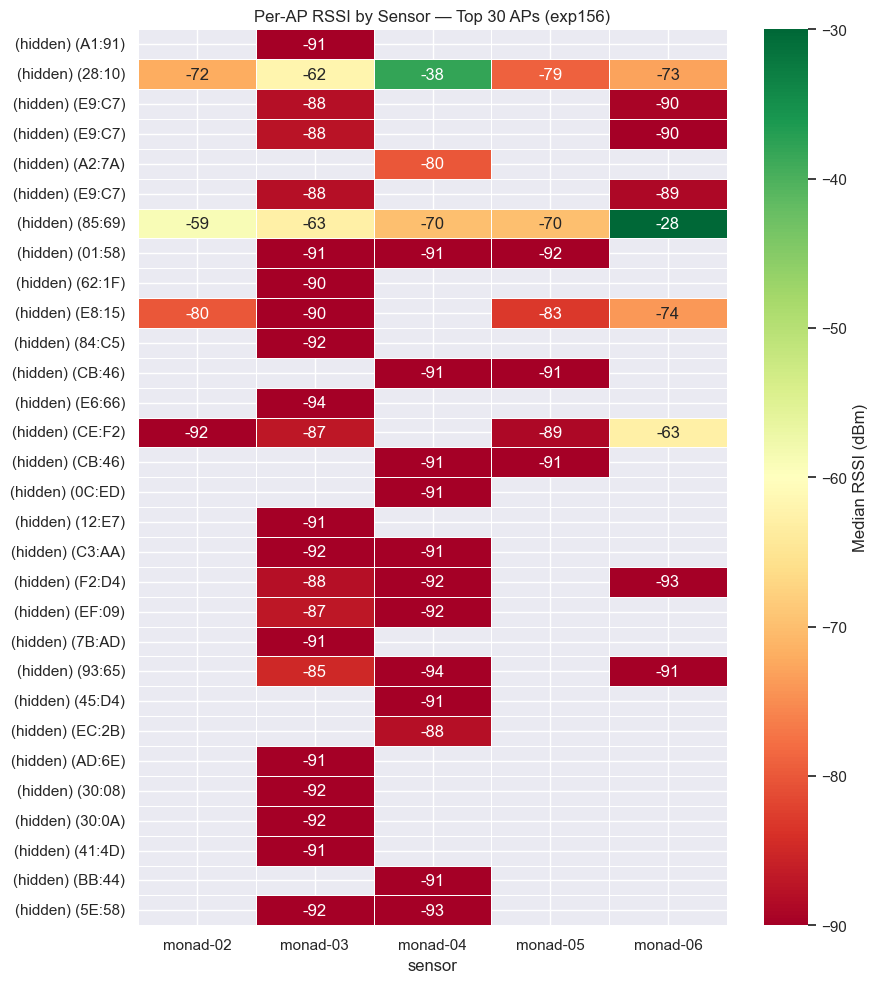

In [7]:
if not ap_inv.empty:
    top_bssids = df.groupby('bssid').size().nlargest(30).index
    df_top = df[df['bssid'].isin(top_bssids)]
    
    pivot = df_top.pivot_table(index='bssid', columns='sensor',
                                values='rssi_dbm', aggfunc='median')
    
    ssid_map = ap_inv.set_index('bssid')['ssid_display']
    pivot.index = [f"{ssid_map.get(b, b)} ({b[-5:]})" for b in pivot.index]
    
    fig, ax = plt.subplots(figsize=(9, 10))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
                vmin=-90, vmax=-30, linewidths=0.4, ax=ax,
                cbar_kws={'label': 'Median RSSI (dBm)'})
    ax.set_title('Per-AP RSSI by Sensor — Top 30 APs (exp156)')
    plt.tight_layout()
    plt.show()


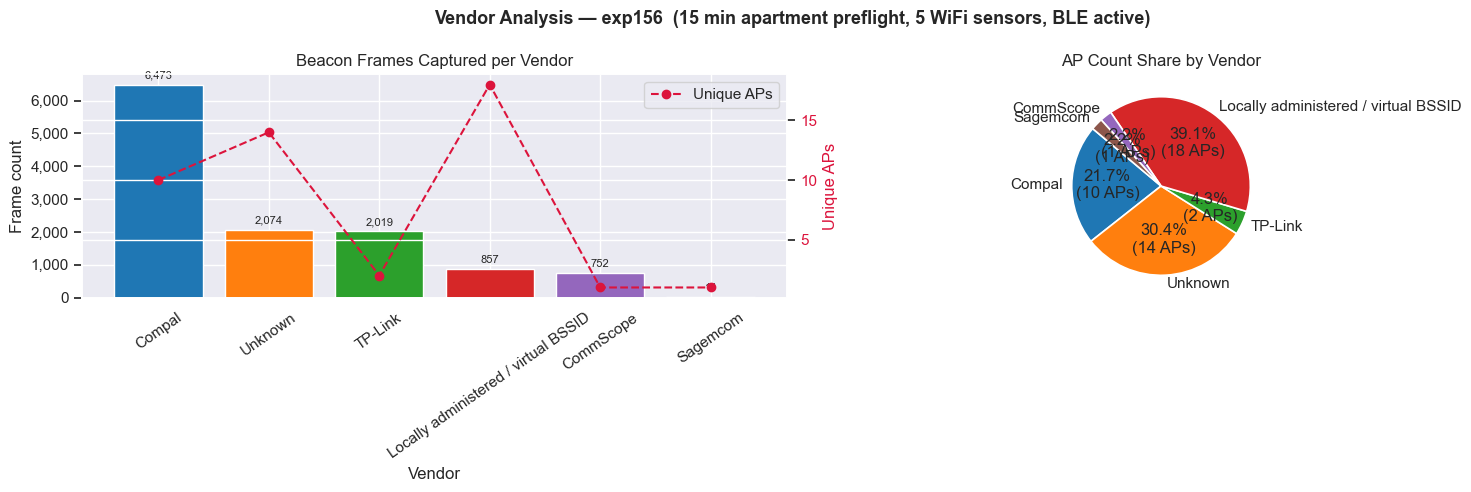

                                      aps  frames
Compal                                 10    6473
Unknown                                14    2074
TP-Link                                 2    2019
Locally administered / virtual BSSID   18     857
CommScope                               1     752
Sagemcom                                1      14


In [8]:
if not ap_inv.empty:
    import matplotlib.gridspec as gridspec

    # ── 1. Per-vendor frame count vs AP count ────────────────────────────────
    vendor_frames = df.groupby(df['bssid'].map(ap_inv.set_index('bssid')['vendor'])).size().rename('frames')
    vendor_aps    = ap_inv['vendor'].value_counts().rename('aps')
    vendor_df = pd.concat([vendor_aps, vendor_frames], axis=1).fillna(0).astype(int)
    vendor_df = vendor_df.sort_values('frames', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Vendor Analysis — exp156  (15 min apartment preflight, 5 WiFi sensors, BLE active)', fontsize=13, fontweight='bold')

    # Bar: frame count
    colors = sns.color_palette('tab10', len(vendor_df))
    bars = axes[0].bar(vendor_df.index, vendor_df['frames'], color=colors, edgecolor='white')
    axes[0].set_title('Beacon Frames Captured per Vendor')
    axes[0].set_ylabel('Frame count')
    axes[0].set_xlabel('Vendor')
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axes[0].bar_label(bars, labels=[f'{v:,}' for v in vendor_df['frames']], padding=3, fontsize=8)

    # Bar: AP count with secondary y-axis
    ax2 = axes[0].twinx()
    ax2.plot(vendor_df.index, vendor_df['aps'], 'o--', color='crimson', linewidth=1.5, markersize=6, label='Unique APs')
    ax2.set_ylabel('Unique APs', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.legend(loc='upper right')

    # Pie: AP share by vendor
    axes[1].pie(vendor_df['aps'], labels=vendor_df.index,
                autopct=lambda p: f'{p:.1f}%\n({int(round(p*vendor_df["aps"].sum()/100))} APs)',
                startangle=140, colors=colors,
                wedgeprops=dict(edgecolor='white', linewidth=1.2))
    axes[1].set_title('AP Count Share by Vendor')

    plt.tight_layout()
    plt.savefig('/Users/admin/FleetManager/artifacts/figures/exp156/ap_vendor_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(vendor_df.to_string())


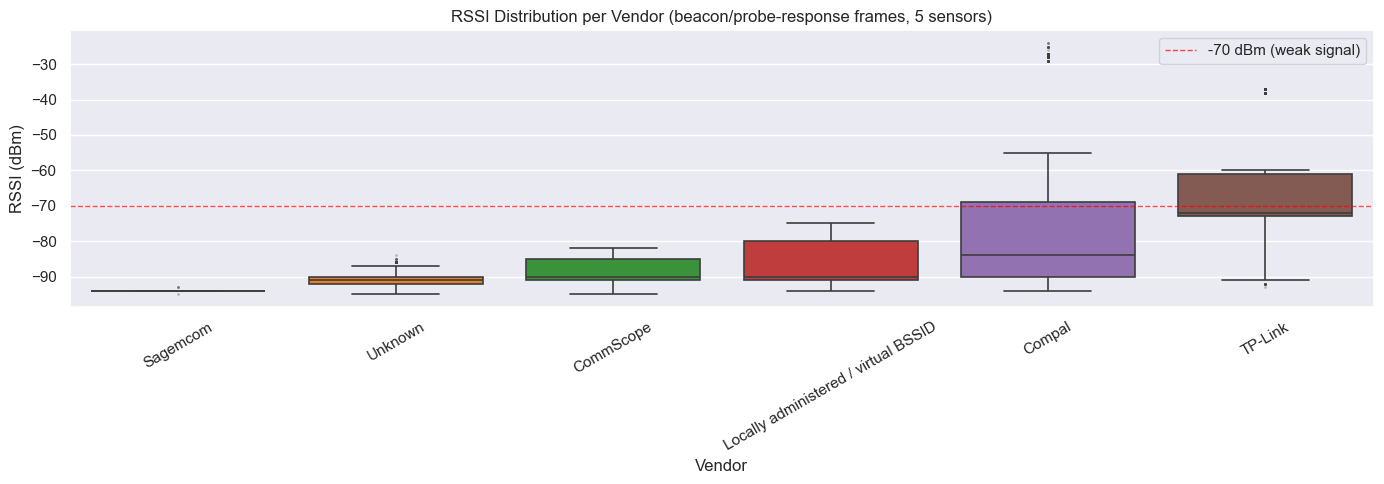

                                      median_rssi  min_rssi  max_rssi  beacon_frames
vendor                                                                              
TP-Link                                     -72.0       -93       -37           2019
Compal                                      -84.0       -94       -24           6473
CommScope                                   -90.0       -95       -82            752
Locally administered / virtual BSSID        -90.0       -94       -75            857
Unknown                                     -91.0       -95       -84           2074
Sagemcom                                    -94.0       -95       -93             14


In [9]:
if not ap_inv.empty:
    # Map each beacon frame to its AP vendor
    bssid_vendor = ap_inv.set_index('bssid')['vendor']
    df_v = df.copy()
    df_v['vendor'] = df_v['bssid'].map(bssid_vendor)
    df_v = df_v.dropna(subset=['rssi_dbm', 'vendor'])

    order = df_v.groupby('vendor')['rssi_dbm'].median().sort_values().index.tolist()

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=df_v, x='vendor', y='rssi_dbm', order=order,
                palette='tab10', linewidth=1.2, ax=ax,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.axhline(-70, color='red', linestyle='--', linewidth=1, alpha=0.7, label='-70 dBm (weak signal)')
    ax.set_title('RSSI Distribution per Vendor (beacon/probe-response frames, 5 sensors)')
    ax.set_xlabel('Vendor')
    ax.set_ylabel('RSSI (dBm)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.savefig('/Users/admin/FleetManager/artifacts/figures/exp156/ap_vendor_rssi_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print median RSSI per vendor
    summary = df_v.groupby('vendor')['rssi_dbm'].agg(['median','min','max','count'])
    summary.columns = ['median_rssi','min_rssi','max_rssi','beacon_frames']
    print(summary.sort_values('median_rssi', ascending=False).to_string())


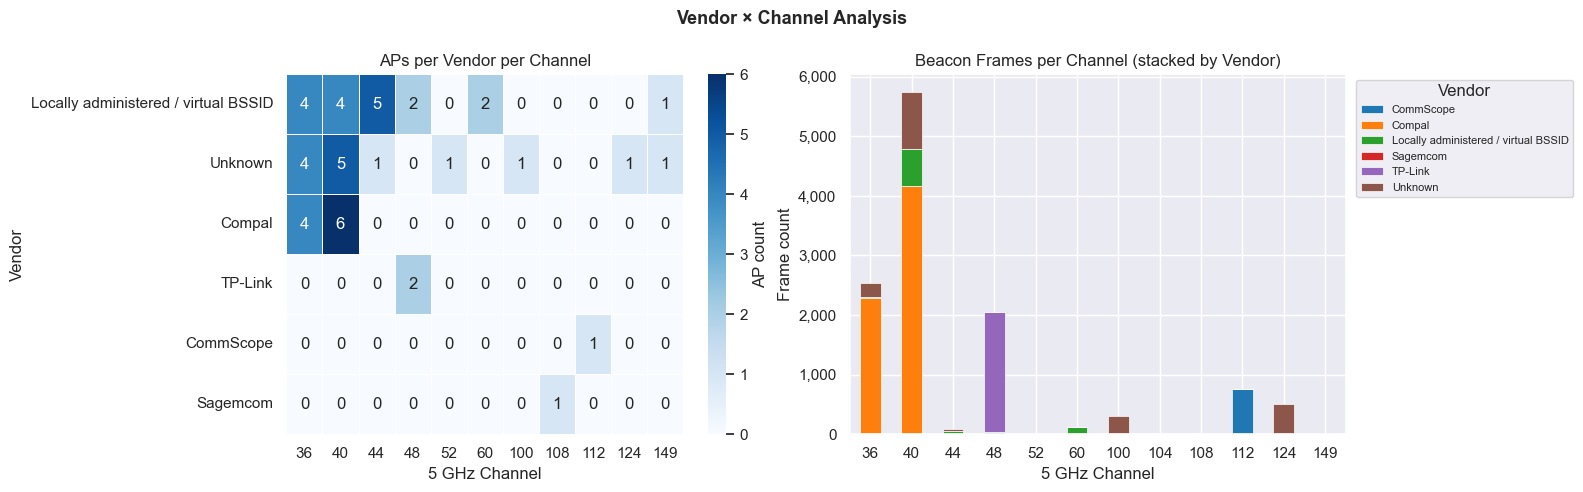

In [10]:
if not ap_inv.empty:
    # How many APs per vendor appear on each channel
    vc_pivot = ap_inv.groupby(['vendor', 'channel']).size().unstack(fill_value=0)
    vc_pivot = vc_pivot.loc[vc_pivot.sum(axis=1).sort_values(ascending=False).index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Vendor × Channel Analysis', fontsize=13, fontweight='bold')

    # Heatmap: AP count per vendor per channel
    sns.heatmap(vc_pivot, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes[0], cbar_kws={'label': 'AP count'})
    axes[0].set_title('APs per Vendor per Channel')
    axes[0].set_xlabel('5 GHz Channel')
    axes[0].set_ylabel('Vendor')
    axes[0].tick_params(axis='x', rotation=0)

    # Stacked bar: frames per channel coloured by vendor
    ch_vendor = df.copy()
    ch_vendor['vendor'] = ch_vendor['bssid'].map(ap_inv.set_index('bssid')['vendor'])
    ch_vendor = ch_vendor.dropna(subset=['vendor', 'channel'])
    ch_vendor['channel'] = ch_vendor['channel'].astype(int)
    cv_pivot = ch_vendor.groupby(['channel', 'vendor']).size().unstack(fill_value=0)
    cv_pivot.plot(kind='bar', stacked=True, ax=axes[1],
                  color=sns.color_palette('tab10', len(cv_pivot.columns)),
                  edgecolor='white', linewidth=0.5)
    axes[1].set_title('Beacon Frames per Channel (stacked by Vendor)')
    axes[1].set_xlabel('5 GHz Channel')
    axes[1].set_ylabel('Frame count')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Vendor', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig('/Users/admin/FleetManager/artifacts/figures/exp156/ap_vendor_channel_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


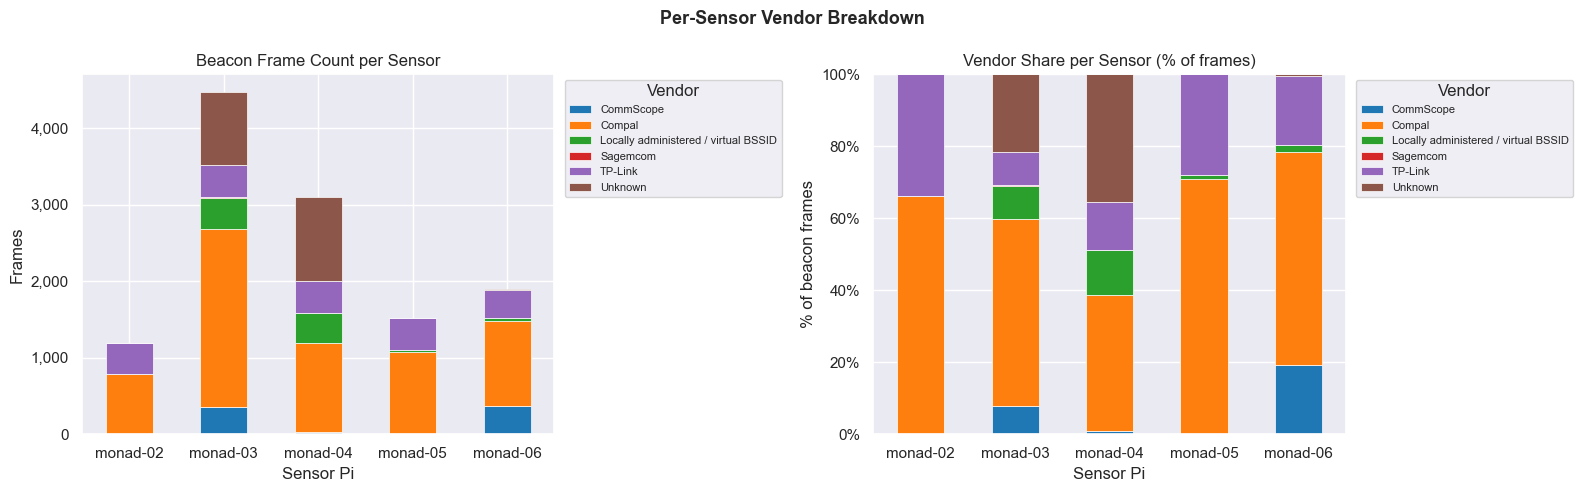


Frames per sensor per vendor:
vendor    CommScope  Compal  Locally administered / virtual BSSID  Sagemcom  TP-Link  Unknown
sensor                                                                                       
monad-02          0     785                                     0         0      403        0
monad-03        356    2323                                   410        14      414      963
monad-04         32    1166                                   389         0      416     1103
monad-05          0    1080                                    18         0      424        0
monad-06        364    1119                                    40         0      362        8

Share (%) per sensor per vendor:
vendor    CommScope  Compal  Locally administered / virtual BSSID  Sagemcom  TP-Link  Unknown
sensor                                                                                       
monad-02        0.0    66.1                                   0.0       0.0     33.9     

In [11]:
if not ap_inv.empty:
    df_sv = df.copy()
    df_sv['vendor'] = df_sv['bssid'].map(ap_inv.set_index('bssid')['vendor'])
    df_sv = df_sv.dropna(subset=['vendor'])

    sensor_vendor = df_sv.groupby(['sensor', 'vendor']).size().unstack(fill_value=0)
    # normalise to % within each sensor
    sensor_pct = sensor_vendor.div(sensor_vendor.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Per-Sensor Vendor Breakdown', fontsize=13, fontweight='bold')

    colors = sns.color_palette('tab10', len(sensor_vendor.columns))

    sensor_vendor.plot(kind='bar', stacked=True, ax=axes[0], color=colors,
                       edgecolor='white', linewidth=0.5)
    axes[0].set_title('Beacon Frame Count per Sensor')
    axes[0].set_ylabel('Frames')
    axes[0].set_xlabel('Sensor Pi')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axes[0].legend(title='Vendor', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

    sensor_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors,
                    edgecolor='white', linewidth=0.5)
    axes[1].set_title('Vendor Share per Sensor (% of frames)')
    axes[1].set_ylabel('% of beacon frames')
    axes[1].set_xlabel('Sensor Pi')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    axes[1].legend(title='Vendor', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.savefig('/Users/admin/FleetManager/artifacts/figures/exp156/ap_vendor_per_sensor.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nFrames per sensor per vendor:")
    print(sensor_vendor.to_string())
    print("\nShare (%) per sensor per vendor:")
    print(sensor_pct.round(1).to_string())


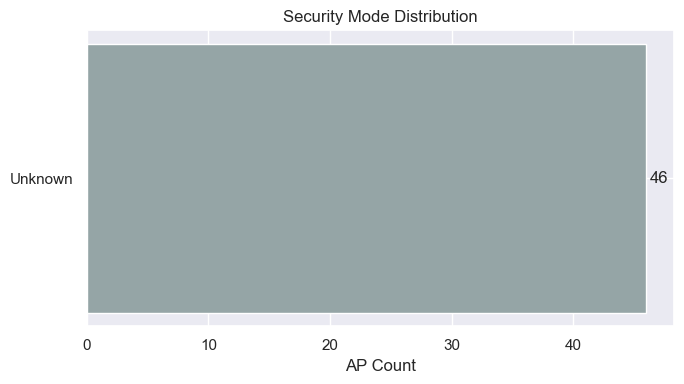

In [12]:
if not ap_inv.empty:
    sec_counts = ap_inv['security'].value_counts()
    
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = {'Open': '#e74c3c', 'WEP': '#e67e22', 'WPA': '#f1c40f',
              'WPA2/WPA3': '#2ecc71', 'WPA2/WPA3+WPA': '#27ae60'}
    bar_colors = [colors.get(s, '#95a5a6') for s in sec_counts.index]
    bars = ax.barh(sec_counts.index, sec_counts.values, color=bar_colors)
    ax.bar_label(bars, padding=3)
    ax.set_xlabel('AP Count')
    ax.set_title('Security Mode Distribution')
    plt.tight_layout()
    plt.show()


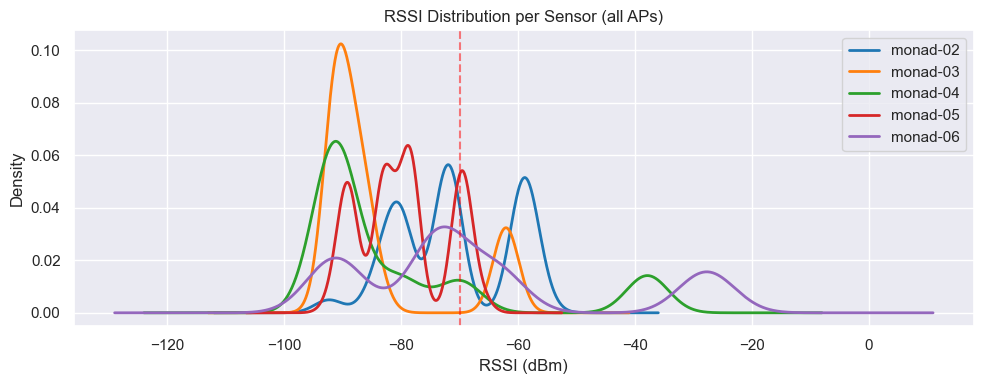

In [13]:
if not ap_inv.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    for sensor, grp in df.groupby('sensor'):
        grp['rssi_dbm'].dropna().plot(kind='kde', ax=ax, label=sensor, linewidth=2)
    ax.set_xlabel('RSSI (dBm)')
    ax.set_ylabel('Density')
    ax.set_title('RSSI Distribution per Sensor (all APs)')
    ax.legend()
    ax.axvline(-70, color='red', linestyle='--', alpha=0.5, label='-70 dBm threshold')
    plt.tight_layout()
    plt.show()


In [14]:
if not ap_inv.empty:
    print('=== Summary ===')
    print(f'Total unique APs detected:   {len(ap_inv)}')
    print(f'Total beacon frames parsed:  {len(df):,}')
    print(f'Sensors used:                {", ".join(PCAPS.keys())}')
    print()
    print('APs per sensor:')
    print(df.groupby('sensor')['bssid'].nunique().to_string())
    print()
    print('Channels in use:', sorted(ap_inv['channel'].unique().tolist()))
    print()
    open_aps = ap_inv[ap_inv['security'].isin(['Open','WEP'])][['ssid_display','bssid','vendor','rssi_median_dbm','security']]
    print('Open/insecure networks:')
    print(open_aps.to_string(index=False) if len(open_aps) else 'None found.')


=== Summary ===
Total unique APs detected:   46
Total beacon frames parsed:  12,189
Sensors used:                monad-02, monad-03, monad-04, monad-05, monad-06

APs per sensor:
sensor
monad-02     4
monad-03    33
monad-04    17
monad-05     7
monad-06    16

Channels in use: [36, 40, 44, 48, 52, 60, 100, 108, 112, 124, 149]

Open/insecure networks:
None found.
